### Load the dataset

In [ ]:
 #! pip install datasets

In [ ]:
#! pip install -U pillow

In [15]:
from datasets import load_dataset

dataset = load_dataset("katanaml-org/invoices-donut-data-v1")

dataset

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a5c51039eab298(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation-00000-of-00001-b8a5c4a62(…):   0%|          | 0.00/19.9M [00:00<?, ?B/s]

data/test-00000-of-00001-56af6bd5ff7eb34(…):   0%|          | 0.00/10.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/425 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 425
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 50
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 26
    })
})

In [16]:
image = dataset["test"][2]["image"]

image.save("test_image.png")

In [17]:
import json
ground_truth = json.loads(dataset["test"][2]["ground_truth"])

In [18]:
ground_truth["gt_parse"]

{'header': {'invoice_no': '62517865',
  'invoice_date': '06/02/2015',
  'seller': 'Trujillo-Hunt 430 Mark Ferry Suite 495 Maxside, DC 65686',
  'client': 'Lee and Sons 8552 Karen Islands East Roger, ID 40416',
  'seller_tax_id': '992-71-8540',
  'client_tax_id': '929-86-0601',
  'iban': 'GB73HCPH34959888432899'},
 'items': [{'item_desc': 'Care & Repair of Furniture',
   'item_qty': '2,00',
   'item_net_price': '4,25',
   'item_net_worth': '8,50',
   'item_vat': '10%',
   'item_gross_worth': '9,35'}],
 'summary': {'total_net_worth': '$ 8,50',
  'total_vat': '$0,85',
  'total_gross_worth': '$9,35'}}

In [131]:
from PIL import Image

In [132]:
import transformers
import huggingface_hub
import accelerate

print(transformers.__version__)
print(huggingface_hub.__version__)
print(accelerate.__version__)


5.2.0
1.4.1
1.12.0


In [45]:
#!pip install transformers==4.45.2
#!pip install accelerate qwen-vl-utils
#!pip install pillow==10.2.0


In [46]:
#! pip install git+https://github.com/huggingface/transformers accelerate

In [47]:
! nvidia-smi

Mon Mar 30 05:43:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   45C    P0            127W /  700W |   19535MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [49]:
#! pip install qwen-vl-utils[decord]==0.0.8


In [ ]:
#! pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

### Load the model and processor

In [35]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

# default: Load the model on the available device(s)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype="auto", device_map="auto"
)

# default processer
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

In [36]:
! nvidia-smi

Mon Mar 23 11:00:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   32C    P0            122W /  700W |   32459MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [50]:
#After training we use this code 
from unsloth import FastVisionModel
from transformers import AutoProcessor

# Load YOUR finetuned model
model, tokenizer = FastVisionModel.from_pretrained("/kaggle/working/qwen_finetuned_full")

# Load processor (same path)
processor = AutoProcessor.from_pretrained("/kaggle/working/qwen_finetuned_full")

# Enable inference mode
#FastVisionModel.for_inference(model)
#model.eval()

==((====))==  Unsloth 2026.3.17: Fast Qwen2_5_Vl patching. Transformers: 5.2.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

In [ ]:
#! nvidia-smi

### Prompt

In [52]:
schema_dict = {
    "header": {
        "invoice_no": "invoice number",
        "invoice_date": "date of invoice",
        "seller": "seller name and address",
        "client": "client name and address",
        "seller_tax_id": "seller tax identification number",
        "client_tax_id": "client tax identification number",
        "iban": "bank IBAN number"
    },
    
    "items": [
        {
            "item_desc": "description of the item",
            "item_qty": "quantity of the item",
            "item_net_price": "price per item before tax",
            "item_net_worth": "total price before tax",
            "item_vat": "VAT percentage",
            "item_gross_worth": "total price after tax"
        }
    ],
    
    "summary": {
        "total_net_worth": "total amount before tax",
        "total_vat": "total VAT amount",
        "total_gross_worth": "final total amount after tax"
    }
}

In [53]:
prompt = f"""
You are a Vision Language Model specialized in extracting structured data from invoice images.

STRICT INSTRUCTIONS (VERY IMPORTANT):

1. OUTPUT FORMAT:
- Return ONLY valid JSON.
- The JSON structure MUST EXACTLY match the provided schema.
- DO NOT add new keys.
- DO NOT nest fields unless explicitly defined in schema.
- DO NOT change key names.

2. HEADER RULES:
- "seller" and "client" MUST be single strings (NOT objects).
- DO NOT create subfields like "name_and_address".
- "seller_tax_id", "client_tax_id", and "iban" must be separate fields inside "header".

3. VALUE FORMATTING (CRITICAL):
- Preserve values EXACTLY as seen in the invoice.
- DO NOT change commas to dots.
- DO NOT add or remove currency symbols.
- DO NOT reformat numbers.

4. ITEMS RULES:
- "item_qty" must contain ONLY numeric value (e.g., "4,00").
- Remove words like "each", "pcs", etc.

5. MISSING VALUES:
- If a field is not present, return it as an empty string "".
- DO NOT remove keys.

6. NO EXTRA TEXT:
- Output ONLY JSON. No explanation.

SCHEMA:
{schema_dict}
"""

In [54]:
def create_messages(image_path, prompt):
    messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
                "resized_height": 640,
                "resized_width": 640
            },
            {"type": "text", "text": prompt},
        ],
    }
]
    return messages

In [138]:
def infer(messages, model, processor):
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")
    
    # Inference: Generation of the output
    generated_ids = model.generate(**inputs, max_new_tokens=2048)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text

In [55]:
#After training 
def infer(messages, model, processor):
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 🔥 extract image directly
    image = messages[0]["content"][0]["image"]

    inputs = processor(
        text=[text],
        images=[image],   # ✅ correct way
        return_tensors="pt"
    )

    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.1,
        )
    # FIX STARTS HERE
    input_len = inputs["input_ids"].shape[1]

    generated_ids = outputs[0][input_len:]   # remove prompt

    prediction = processor.tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return prediction.strip()
    # we use this code before training 
    #return processor.tokenizer.decode(outputs[0], skip_special_tokens=True)

In [56]:
import os

if not os.path.exists("tests"):
    os.mkdir("tests")

In [57]:
import json
from tqdm import tqdm

i = 0
prediction_list = []
ground_truth_list = []

for row in tqdm(dataset["test"]):
    image = row["image"]
    image_path = os.path.join("tests", f"test_{i}.png")
    image.save(image_path)

    ground_truth = json.loads(row["ground_truth"])["gt_parse"]
    ground_truth_list.append(ground_truth)

    messages = create_messages(image_path=image_path, prompt=prompt)

    prediction = infer(messages=messages, model=model, processor=processor)
    prediction_list.append(prediction)
    i += 1

100%|██████████| 26/26 [12:54<00:00, 29.77s/it]


In [ ]:
import re

prediction = re.sub(r"```json|```", "", prediction).strip()

In [58]:
results = {
    "predictions": prediction_list,
    "ground_truth": ground_truth_list
}

with open("results.json", "w") as f:
    json.dump(results, f)

In [59]:
with open("results.json") as f:
    results = json.load(f)

prediction_list = results["predictions"]
ground_truth_list = results["ground_truth"]

In [60]:
prediction_list[2]

'{"header": {"invoice_no": "62517865", "invoice_date": "06/02/2015", "seller": "Trujillo-Hunt 430 Mark Ferry Suite 495 Maxside, DC 65686", "client": "Lee and Sons 8552 Karen Islands East Roger, ID 40416", "seller_tax_id": "992-71-8540", "client_tax_id": "929-86-0601", "iban": "GB73HCPH34959888432899"}, "items": [{"item_desc": "Care & Repair of Furniture", "item_qty": "2,00", "item_net_price": "4,25", "item_net_worth": "8,50", "item_vat": "10%", "item_gross_worth": "9,35"}], "summary": {"total_net_worth": "$ 8,50", "total_vat": "$ 0,85", "total_gross_worth": "$ 9,35"}}'

In [ ]:
#ground_truth_list[1]

In [ ]:
import re
import json

def postprocess(prediction):
    # 1. Remove markdown (```json)
    prediction = re.sub(r"```json|```", "", prediction).strip()

    # 2. Try converting to dict
    try:
        prediction = json.loads(prediction)
    except:
        prediction = {}   # fallback if parsing fails

    return prediction

In [62]:
prediction_list = [postprocess(x) for x in prediction_list]

In [63]:
import json

prediction_dict = json.loads(prediction)

In [64]:
ground_truth_list[1]

{'header': {'invoice_no': '13194726',
  'invoice_date': '05/29/2021',
  'seller': 'Hopkins and Sons 62283 Flores Tunnel North Luis, IA 69983',
  'client': 'Sims PLC USS Kramer FPO AA 81651',
  'seller_tax_id': '952-73-7223',
  'client_tax_id': '995-88-9495',
  'iban': 'GB31LZX520242755934691'},
 'items': [{'item_desc': 'Beach Lunch Lounge Striped Shirt Dress Large Navy Blue White Long Sleeve Causal',
   'item_qty': '1,00',
   'item_net_price': '16,99',
   'item_net_worth': '16,99',
   'item_vat': '10%',
   'item_gross_worth': '18,69'},
  {'item_desc': 'Jams World Hawaiian 0 Dress Rayon SZ.L',
   'item_qty': '5,00',
   'item_net_price': '65,00',
   'item_net_worth': '325,00',
   'item_vat': '10%',
   'item_gross_worth': '357,50'},
  {'item_desc': 'LuLaRoe Nicole Dress Size Large 26',
   'item_qty': '2,00',
   'item_net_price': '1,99',
   'item_net_worth': '3,98',
   'item_vat': '10%',
   'item_gross_worth': '4,38'},
  {'item_desc': 'Johnny Was Medium Linen Wrap Dress Dessert Rose Embroi

In [65]:
def flatten_dict(data):

    flat = {}

    # HEADER
    if "header" in data:
        for k, v in data["header"].items():
            flat[f"header.{k}"] = v

    # ITEMS
    if "items" in data:
        for i, item in enumerate(data["items"]):
            for k, v in item.items():
                flat[f"items.{i}.{k}"] = v

    # SUMMARY
    if "summary" in data:
        for k, v in data["summary"].items():
            flat[f"summary.{k}"] = v

    return flat

In [66]:
prediction_list[13]

{'header': {'invoice_no': '96051364',
  'invoice_date': '04/28/2020',
  'seller': 'Jackson Ltd 134 Catherine Valley Apt. 756 Lake Jennifer, NE 09531',
  'client': 'Williams, Fowler and Phillips 115 McCormick Knolls North Kevin, TN 27580',
  'seller_tax_id': '914-85-0938',
  'client_tax_id': '963-87-9620',
  'iban': 'GB61XXNT90578783067262'},
 'items': [{'item_desc': '49"x22" Marble Top Center Table Carnelian Mosaic Italian Art Christmas Gift Arts',
   'item_qty': '4,00',
   'item_net_price': '2 400,00',
   'item_net_worth': '9 600,00',
   'item_vat': '10%',
   'item_gross_worth': '10 560,00'},
  {'item_desc': "6'x3' Marble Dining Center Table With Black Top Floral Collectible Inlaid E963",
   'item_qty': '3,00',
   'item_net_price': '6 040,40',
   'item_net_worth': '18 121,20',
   'item_vat': '10%',
   'item_gross_worth': '19 933,32'},
  {'item_desc': "7'x4' Blue Random Marble Dining Hallway Table Top Lapis Lazuli Inlay Decor E947A",
   'item_qty': '5,00',
   'item_net_price': '8 194,0

In [67]:
ground_truth_list[13]

{'header': {'invoice_no': '96051364',
  'invoice_date': '04/28/2020',
  'seller': 'Jackson Ltd 134 Catherine Valley Apt. 756 Lake Jennifer, NE 09531',
  'client': 'Williams, Fowler and Phillips 115 Mccormick Knolls North Kevin, TN 27580',
  'seller_tax_id': '914-85-0938',
  'client_tax_id': '963-87-9620',
  'iban': 'GB61XXNT90578783067262'},
 'items': [{'item_desc': '49"x22" Marble Top Center Table Carnelian Mosaic Italian Art Christmas Gift Arts',
   'item_qty': '4,00',
   'item_net_price': '2400,00',
   'item_net_worth': '9600,00',
   'item_vat': '10%',
   'item_gross_worth': '10 560,00'},
  {'item_desc': "6'x3' Marble Dining Center Table With Black Top Floral Collectible Inlaid E963",
   'item_qty': '3,00',
   'item_net_price': '6040,40',
   'item_net_worth': '18 121,20',
   'item_vat': '10%',
   'item_gross_worth': '19 933,32'},
  {'item_desc': "7'x4' Blue Random Marble Dining Hallway Table Top Lapis Lazuli Inlay Decor E947A",
   'item_qty': '5,00',
   'item_net_price': '8194,09',


In [68]:
metrics_list = []

for i in range(len(prediction_list)):
    
    metrics_dict = {}
    gt = ground_truth_list[i]
    pred = prediction_list[i]

    # ensure items exist
    if "items" in gt and isinstance(gt["items"], dict):
        gt["items"] = [gt["items"]]

    if "items" in pred and isinstance(pred["items"], dict):
        pred["items"] = [pred["items"]]

    gt_flat = flatten_dict(gt)
    pred_flat = flatten_dict(pred)

    total_keys = len(gt_flat)
    matched_keys = 0
    
    for key, gt_value in gt_flat.items():
        pred_value = pred_flat.get(key, "")

        if gt_value == pred_value:
            matched_keys += 1

    metrics_dict["invoice_no"] = i
    metrics_dict["total_keys"] = total_keys
    metrics_dict["matched_keys"] = matched_keys
    metrics_dict["accuracy"] = (matched_keys / total_keys) * 100

    metrics_list.append(metrics_dict)

In [69]:
import pandas as pd

metrics_df = pd.DataFrame(metrics_list)

metrics_df.round(2)

,invoice_no,total_keys,matched_keys,accuracy
0,0,16,13,81.25
1,1,46,41,89.13
2,2,16,14,87.50
3,3,22,17,77.27
4,4,52,45,86.54
5,5,40,32,80.00
6,6,40,37,92.50
7,7,16,15,93.75
8,8,28,24,85.71
9,9,16,13,81.25


In [70]:
metrics_df["accuracy"].mean()

np.float64(87.20530084709702)

In [71]:
print("Average Invoice Accuracy:", round(metrics_df["accuracy"].mean(),2),"%")
print("Best Invoice Accuracy:", round(metrics_df["accuracy"].max(),2),"%")
print("Worst Invoice Accuracy:", round(metrics_df["accuracy"].min(),2),"%")

Average Invoice Accuracy: 87.21 %
Best Invoice Accuracy: 97.83 %
Worst Invoice Accuracy: 71.74 %


In [72]:
def extract_values(data, level, key):
    values = []
    if level == "sub" and isinstance(data, dict) and "sub" in data["items"]:
      menu = data["items"]
    else:
      menu = data.get(level, [])
    if isinstance(menu, dict):
        if key in menu:
            values.append(menu[key])
    else:
        for item in menu:
            if key in item:
                values.append(item[key])

    return values


In [157]:
#prediction_list[1]

In [73]:
extract_values(data=prediction_list[0], level="items", key="item_desc")

['12" Marble Lapis Inlay Chess Table Top With 2" Pieces & 15" Wooden Stand W537']

In [74]:
keys_to_evaluate = []

keys = ["header", "items", "summary"]

for k in keys:

    if k == "items":
        d = schema_dict["items"][0]   # because items is a list
    else:
        d = schema_dict[k]

    for k1 in d.keys():
        keys_to_evaluate.append(f"{k}.{k1}")

print(keys_to_evaluate)

['header.invoice_no', 'header.invoice_date', 'header.seller', 'header.client', 'header.seller_tax_id', 'header.client_tax_id', 'header.iban', 'items.item_desc', 'items.item_qty', 'items.item_net_price', 'items.item_net_worth', 'items.item_vat', 'items.item_gross_worth', 'summary.total_net_worth', 'summary.total_vat', 'summary.total_gross_worth']


In [75]:

from collections import Counter


def compute_metrics(gt_values, pred_values):
    """Computes Precision, Recall, F1-score, and Accuracy for exact matches."""

    gt_counter = Counter(gt_values)
    pred_counter = Counter(pred_values)

    tp = 0  # True Positives (Correct Matches)
    fp = 0  # False Positives (Extra Predictions)
    fn = 0  # False Negatives (Missing Predictions)

    matched_pred = set()

    # Exact Matches
    for val in gt_counter:
        if val in pred_counter:
            tp += min(gt_counter[val], pred_counter[val])  # Count matches
            matched_pred.add(val)

    # Compute FP (Extra Predictions not in GT)
    fp = sum(pred_counter[val] for val in pred_counter if val not in matched_pred)

    # Compute FN (Missing Predictions in GT)
    fn = sum(gt_counter[val] for val in gt_counter if val not in matched_pred)

    return {"tp": tp, "fp": fp, "fn": fn}

In [76]:
i = 0

metrics = {key: {"tp": 0, "fp": 0, "fn": 0, "total_gt": 0} for key in keys_to_evaluate}
for gt, pred in zip(ground_truth_list, prediction_list):
    for key in keys_to_evaluate:
        level, sub_level = key.split('.')
        gt_values = extract_values(data=gt, level=level, key=sub_level)
        pred_values = extract_values(data=pred, level=level, key=sub_level)
        # print(key, gt_values, pred_values)

        gt_values = [str(x) for x in gt_values]
        pred_values = [str(x) for x in pred_values]

        # compute the precision, recall and f1-score for the key    
        instance_metrics = compute_metrics(gt_values, pred_values)
        # print(key, instance_metrics)

        metrics[key]["tp"] += instance_metrics["tp"]
        metrics[key]["fp"] += instance_metrics["fp"]
        metrics[key]["fn"] += instance_metrics["fn"]
        metrics[key]["total_gt"] += len(gt_values)


In [77]:
final_metrics = []

for key, value in metrics.items():
    tp, fp, fn, total_gt = value["tp"], value["fp"], value["fn"], value["total_gt"]

    # precision
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # Recall
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # F1-score
    f1_score = ( 2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Accuracy
    accuracy = tp / total_gt if total_gt > 0 else 0

    final_metrics.append({
        "key" : key,
        "precision" : precision,
        "recall" : recall,
        "f1-score" : f1_score,
        "tp" : tp,
        "total_gt": total_gt,
        "accuracy" : accuracy
    })


In [78]:
final_metrics_df = pd.DataFrame(final_metrics)

final_metrics_df[final_metrics_df["total_gt"] > 0]

,key,precision,recall,f1-score,tp,total_gt,accuracy
0,header.invoice_no,1.000000,1.000000,1.000000,26,26,1.000000
1,header.invoice_date,1.000000,1.000000,1.000000,26,26,1.000000
2,header.seller,0.884615,0.884615,0.884615,23,26,0.884615
3,header.client,0.923077,0.923077,0.923077,24,26,0.923077
4,header.seller_tax_id,0.961538,1.000000,0.980392,25,25,1.000000
5,header.client_tax_id,1.000000,1.000000,1.000000,26,26,1.000000
6,header.iban,0.730769,0.730769,0.730769,19,26,0.730769
7,items.item_desc,0.811321,0.811321,0.811321,86,106,0.811321
8,items.item_qty,1.000000,1.000000,1.000000,106,106,1.000000
9,items.item_net_price,0.933962,0.933962,0.933962,99,106,0.933962


In [79]:
import numpy as np

overall_accuracy = np.mean([m["accuracy"] for m in metrics_list])

print("🔥 Overall Accuracy:", overall_accuracy)

🔥 Overall Accuracy: 87.20530084709702


In [81]:
metrics_list = []
all_field_stats = {}

for i in range(len(prediction_list)):

    gt = ground_truth_list[i]
    pred = prediction_list[i]

    # Fix item format
    if "items" in gt and isinstance(gt["items"], dict):
        gt["items"] = [gt["items"]]

    if "items" in pred and isinstance(pred["items"], dict):
        pred["items"] = [pred["items"]]

    gt_flat = flatten_dict(gt)
    pred_flat = flatten_dict(pred)

    total_keys = len(gt_flat)
    matched_keys = 0

    for key, gt_value in gt_flat.items():
        pred_value = pred_flat.get(key, "")

        # Track per-field stats
        if key not in all_field_stats:
            all_field_stats[key] = {"correct": 0, "total": 0}

        all_field_stats[key]["total"] += 1

        if gt_value == pred_value:
            matched_keys += 1
            all_field_stats[key]["correct"] += 1

    accuracy = (matched_keys / total_keys) * 100 if total_keys > 0 else 0

    metrics_list.append({
        "invoice_id": i,
        "total_keys": total_keys,
        "matched_keys": matched_keys,
        "accuracy": accuracy
    })

In [82]:
field_accuracy = {}

for key, stats in all_field_stats.items():
    field_accuracy[key] = stats["correct"] / stats["total"]

print("\n📊 Field-wise Accuracy:")
for k, v in field_accuracy.items():
    print(f"{k}: {v:.2f}")


📊 Field-wise Accuracy:
header.invoice_no: 1.00
header.invoice_date: 1.00
header.seller: 0.88
header.client: 0.92
header.seller_tax_id: 1.00
header.client_tax_id: 1.00
header.iban: 0.73
items.0.item_desc: 0.77
items.0.item_qty: 1.00
items.0.item_net_price: 0.96
items.0.item_net_worth: 0.92
items.0.item_vat: 1.00
items.0.item_gross_worth: 0.92
summary.total_net_worth: 0.42
summary.total_vat: 0.35
summary.total_gross_worth: 0.50
items.1.item_desc: 0.81
items.1.item_qty: 1.00
items.1.item_net_price: 0.95
items.1.item_net_worth: 0.95
items.1.item_vat: 1.00
items.1.item_gross_worth: 0.81
items.2.item_desc: 0.89
items.2.item_qty: 1.00
items.2.item_net_price: 0.94
items.2.item_net_worth: 0.94
items.2.item_vat: 1.00
items.2.item_gross_worth: 0.83
items.3.item_desc: 0.87
items.3.item_qty: 1.00
items.3.item_net_price: 0.93
items.3.item_net_worth: 0.93
items.3.item_vat: 1.00
items.3.item_gross_worth: 0.87
items.4.item_desc: 0.79
items.4.item_qty: 1.00
items.4.item_net_price: 0.86
items.4.item_net

In [64]:
#!pip install rapidfuzz

In [ ]:
import os
os.environ["HF_TOKEN"] = "Write HF Tokens"

import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
#del model
#del trainer
#del tokenizer

In [3]:
import gc
gc.collect()

85

## Let's do Fine Tuning of the Model 

In [36]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab and Kaggle notebooks! Otherwise use pip install unsloth
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29 peft trl triton
    !pip install --no-deps cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [37]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct",
    #"unsloth/Qwen2.5-VL-3B-Instruct-bnb-4bit",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

/tmp/ipykernel_106/2096151251.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel # FastLanguageModel for LLMs


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.17: Fast Qwen2_5_Vl patching. Transformers: 5.2.0.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

In [38]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 64,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 64,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

In [39]:
# Fix tokenizer
if tokenizer.bos_token is None:
    tokenizer.bos_token = tokenizer.eos_token

model.config.bos_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id

# Disable checkpointing
model.gradient_checkpointing_disable()
model.config.use_cache = True

# Disable fused CE (optional but safe)
import os
os.environ["UNSLOTH_DISABLE_FUSED_CE"] = "1"

# IMPORTANT: override Unsloth training mode
FastVisionModel.for_training(model, use_gradient_checkpointing=False)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1280, out_features=3840, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1280, out_features=64,

In [40]:
from datasets import load_dataset

dataset = load_dataset("katanaml-org/invoices-donut-data-v1",split="train")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a5c51039eab298(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation-00000-of-00001-b8a5c4a62(…):   0%|          | 0.00/19.9M [00:00<?, ?B/s]

data/test-00000-of-00001-56af6bd5ff7eb34(…):   0%|          | 0.00/10.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/425 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/26 [00:00<?, ? examples/s]

In [41]:
val_dataset   = load_dataset("katanaml-org/invoices-donut-data-v1", split="validation")

In [42]:
dataset

Dataset({
    features: ['image', 'ground_truth'],
    num_rows: 425
})

In [43]:
schema_dict = {
    "header": {
        "invoice_no": "invoice number",
        "invoice_date": "date of invoice",
        "seller": "seller name and address",
        "client": "client name and address",
        "seller_tax_id": "seller tax identification number",
        "client_tax_id": "client tax identification number",
        "iban": "bank IBAN number"
    },
    
    "items": [
        {
            "item_desc": "description of the item",
            "item_qty": "quantity of the item",
            "item_net_price": "price per item before tax",
            "item_net_worth": "total price before tax",
            "item_vat": "VAT percentage",
            "item_gross_worth": "total price after tax"
        }
    ],
    
    "summary": {
        "total_net_worth": "total amount before tax",
        "total_vat": "total VAT amount",
        "total_gross_worth": "final total amount after tax"
    }
}

In [44]:
import json
instruction = f"""You are a specialized in invoice and your role is to extract information from any invoice that is provided to you in the following valid json format. if the corresponding value is not present, leave the key with empty string.

{json.dumps(schema_dict)}

Fill the keys only when the information is available.
"""

In [45]:
def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["ground_truth"]} ]
        },
    ]
    return { "messages" : conversation }


In [46]:
print(dataset[0].keys())

dict_keys(['image', 'ground_truth'])


In [47]:
import json
from tqdm import tqdm

converted_dataset = []

for sample in tqdm(dataset):
    gt = sample["ground_truth"]

    if isinstance(gt, str):
        gt = json.loads(gt)

    if isinstance(gt, dict) and "gt_parse" in gt:
        gt = gt["gt_parse"]

    sample["ground_truth"] = json.dumps(gt)

    sample["image"] = sample["image"].resize((512, 512))

    converted_dataset.append(convert_to_conversation(sample))

100%|██████████| 425/425 [00:33<00:00, 12.80it/s]


In [48]:
print(converted_dataset[0].keys())


dict_keys(['messages'])


In [49]:
converted_dataset[200]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'You are a specialized in invoice and your role is to extract information from any invoice that is provided to you in the following valid json format. if the corresponding value is not present, leave the key with empty string.\n\n{"header": {"invoice_no": "invoice number", "invoice_date": "date of invoice", "seller": "seller name and address", "client": "client name and address", "seller_tax_id": "seller tax identification number", "client_tax_id": "client tax identification number", "iban": "bank IBAN number"}, "items": [{"item_desc": "description of the item", "item_qty": "quantity of the item", "item_net_price": "price per item before tax", "item_net_worth": "total price before tax", "item_vat": "VAT percentage", "item_gross_worth": "total price after tax"}], "summary": {"total_net_worth": "total amount before tax", "total_vat": "total VAT amount", "total_gross_worth": "final total amount after tax"}}\n\nFil

In [19]:
sample = converted_dataset[0]

print(sample.keys())

dict_keys(['messages'])


In [16]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator
from unsloth import is_bf16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = converted_dataset,

    args = SFTConfig(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 1,   # 🔥 FIXED

        num_train_epochs = 3,
        learning_rate = 5e-4,              # 🔥 FIXED
        warmup_steps = 10,                 # 🔥 FIXED

        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        seed = 3407,
        logging_steps = 1,

        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",

        max_grad_norm = 1.0,

        output_dir = "outputs",

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},

        max_seq_length = 1024,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [51]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 425 | Num Epochs = 3 | Total steps = 1,275
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 1 x 1) = 1
 "-____-"     Trainable parameters = 206,086,144 of 8,498,252,800 (2.43% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.688007
2,1.476431
3,0.987685
4,0.816033
5,0.625195
6,0.520045
7,0.643331
8,0.446957
9,0.287785
10,0.270419


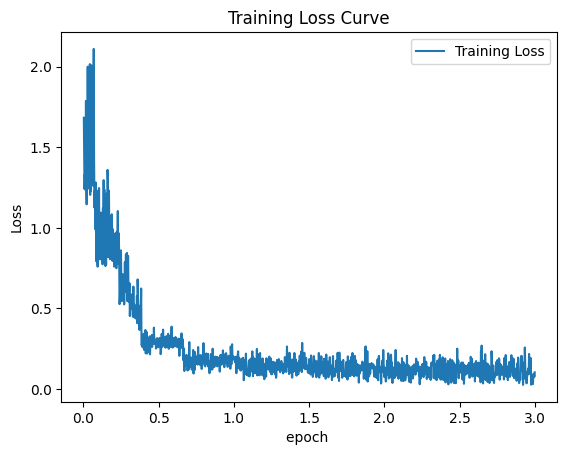

In [38]:
import matplotlib.pyplot as plt

# get logs from trainer
logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["epoch"])

# plot
plt.figure()
plt.plot(steps, train_loss, label="Training Loss")

plt.xlabel("epoch ")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()

plt.show()

In [53]:
from transformers import AutoProcessor

# Load processor
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")

# Merge model (if using LoRA)
model = trainer.model
model = model.merge_and_unload()

# Save path
save_path = "/kaggle/working/qwen_finetuned_full"

# Save model + processor
model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print("✅ Full fine-tuned model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Full fine-tuned model saved!


In [35]:
!pip install -q huggingface_hub

from huggingface_hub import login
login("Write Hf tokens here!")

In [36]:
from huggingface_hub import HfApi

api = HfApi()

repo_id = "wrire repo id here!"

# Create repo
api.create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

# Upload full folder
api.upload_folder(
    folder_path="/kaggle/working/qwen_finetuned_full",
    repo_id=repo_id,
    repo_type="model"
)

print("✅ Model uploaded successfully!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Model uploaded successfully!
